In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
from pathlib import Path

csv_path = Path(r"C:/Users/user/Desktop/Data-Science-/DataApps/Health Insurance Cost\Data\insurance.csv")
print("File exists:", csv_path.exists())

df = pd.read_csv(csv_path)

File exists: True


In [3]:
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01
...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.0,female,35.5,88,Yes,0,Yes,northwest,55135.40
1336,1337,59.0,female,38.1,120,No,1,Yes,northeast,58571.07
1337,1338,30.0,male,34.5,91,Yes,3,Yes,northwest,60021.40
1338,1339,37.0,male,30.4,106,No,0,Yes,southeast,62592.87


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1340 non-null   int64  
 1   age            1335 non-null   float64
 2   gender         1340 non-null   str    
 3   bmi            1340 non-null   float64
 4   bloodpressure  1340 non-null   int64  
 5   diabetic       1340 non-null   str    
 6   children       1340 non-null   int64  
 7   smoker         1340 non-null   str    
 8   region         1337 non-null   str    
 9   claim          1340 non-null   float64
dtypes: float64(3), int64(3), str(4)
memory usage: 129.4 KB


In [5]:
df.duplicated().sum().sum()

np.int64(0)

In [6]:
df.isna().sum()

Id               0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

In [7]:
df.dropna(inplace=True)

In [8]:
df.isna().sum()

Id               0
age              0
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           0
claim            0
dtype: int64

In [9]:
df.describe()

,Id,age,bmi,bloodpressure,children,claim
count,1332.000000,1332.000000,1332.000000,1332.000000,1332.000000,1332.000000
mean,674.474474,38.086336,30.658333,94.189189,1.099850,13325.246426
std,384.703785,11.112804,6.118967,11.445173,1.205958,12109.620712
min,1.000000,18.000000,16.000000,80.000000,0.000000,1121.870000
25%,341.750000,29.000000,26.200000,86.000000,0.000000,4760.157500
50%,674.500000,38.000000,30.350000,92.000000,1.000000,9412.965000
75%,1007.250000,47.000000,34.725000,99.000000,2.000000,16781.327500
max,1340.000000,60.000000,53.100000,140.000000,5.000000,63770.430000


Text(0.5, 0.98, 'Distribution of Numerical Features')

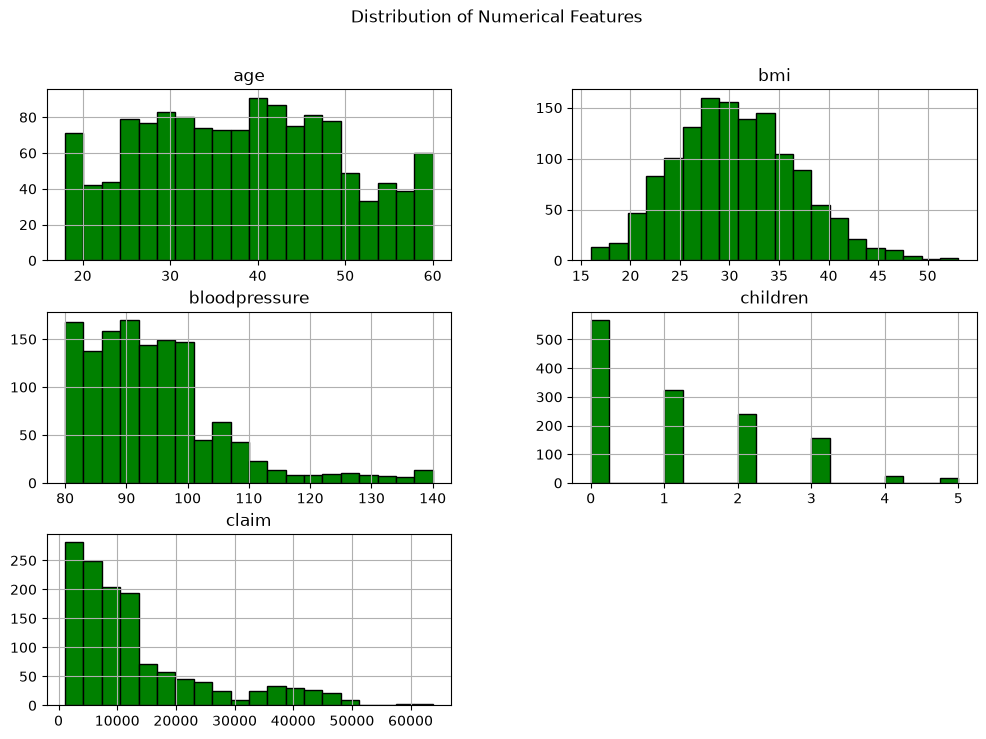

In [10]:
num_col = ['age', 'bmi', 'bloodpressure', 'children', 'claim']
df[num_col].hist(bins=20, figsize=(12, 8), color='green', edgecolor='black')
plt.suptitle("Distribution of Numerical Features")

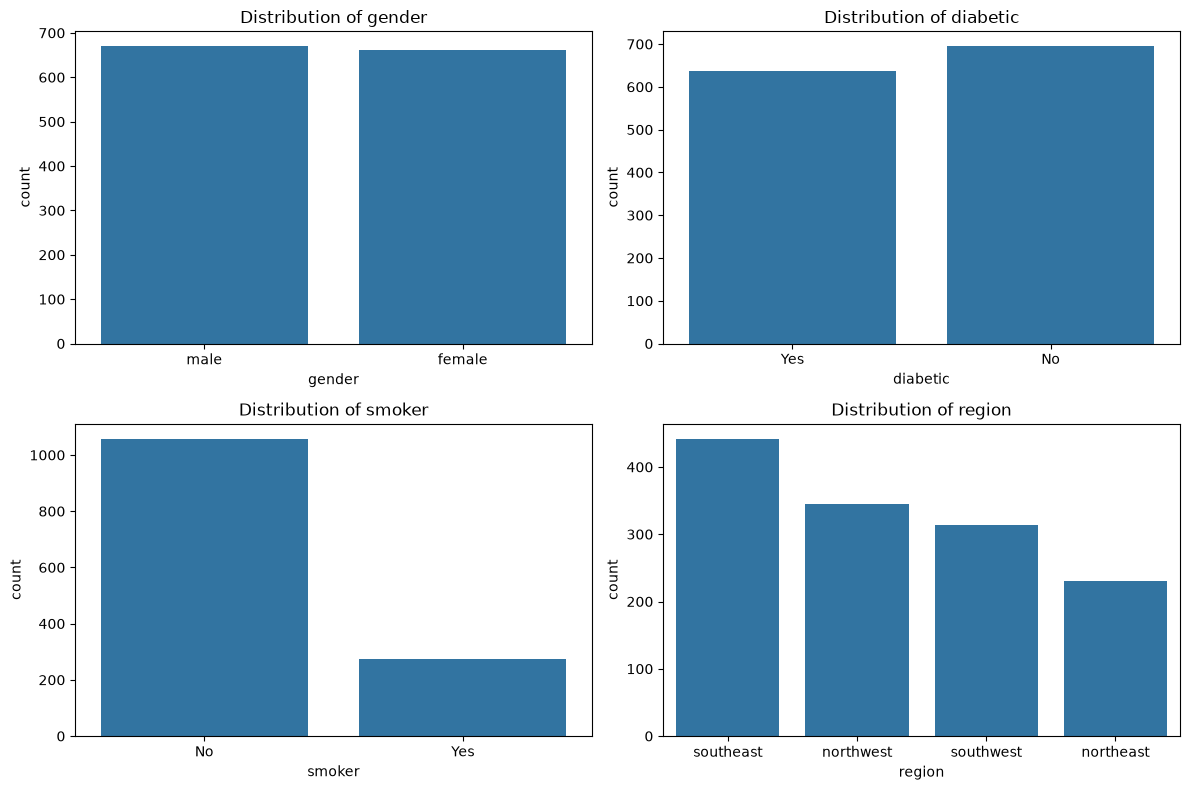

In [11]:
cat_col = ['gender', 'diabetic', 'smoker', 'region']

plt.figure(figsize=(12, 8))

for i, col in enumerate(cat_col, 1):
    plt.subplot(2, 2, i)
    sns.countplot(data=df, x= col)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

In [12]:
df.groupby(['gender', 'smoker'])['claim'].mean().round(2)

gender  smoker
female  No         8762.30
        Yes       30679.00
male    No         8169.25
        Yes       33042.01
Name: claim, dtype: float64

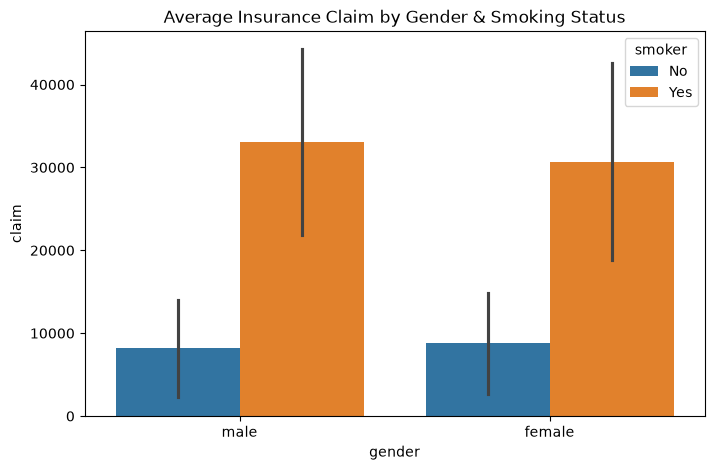

In [13]:
plt.figure(figsize=(8, 5))
sns.barplot(data = df, x = 'gender', y = 'claim', hue = 'smoker', estimator='mean', errorbar='sd')
plt.title("Average Insurance Claim by Gender & Smoking Status")
plt.show()

In [14]:
pivot_region_diabetic = df.groupby(['region', 'diabetic'])['claim'].mean().unstack()

In [15]:
pivot_region_diabetic

diabetic,No,Yes
region,,
northeast,16966.861455,16818.302231
northwest,11442.831842,12224.958000
southeast,13578.717200,12574.093226
southwest,13069.907824,12313.739167


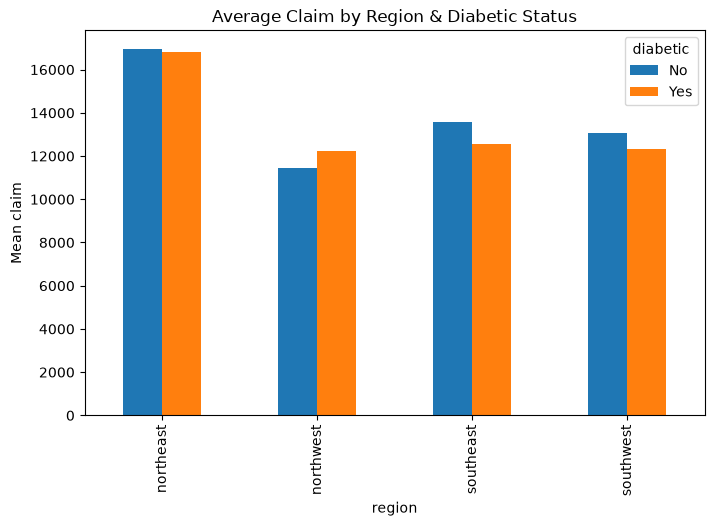

In [16]:
pivot_region_diabetic.plot(kind = 'bar', figsize=(8,5))
plt.title('Average Claim by Region & Diabetic Status')
plt.ylabel('Mean claim')
plt.show()

In [17]:
pivot_table = pd.pivot_table(df, values='claim', index='region', columns = 'smoker')
pivot_table

smoker,No,Yes
region,,
northeast,11666.112195,29673.536269
northwest,8076.203415,30192.002759
southeast,7444.144872,34844.997253
southwest,8294.754102,32269.064138


In [18]:
pivot_table = pd.pivot_table(df, values='claim', index='children', columns = 'diabetic', aggfunc = 'mean')
pivot_table

diabetic,No,Yes
children,,
0,12967.395398,11985.289857
1,12730.455810,12732.055724
2,15567.767583,14579.360417
3,13807.612892,17091.258649
4,14106.630000,13573.352500
5,8519.043636,9205.594286


In [19]:
df[num_col]

,age,bmi,bloodpressure,children,claim
0,39.0,23.2,91,0,1121.87
1,24.0,30.1,87,0,1131.51
7,19.0,41.1,100,0,1146.80
8,20.0,43.0,86,0,1149.40
9,30.0,53.1,97,0,1163.46
...,...,...,...,...,...
1335,44.0,35.5,88,0,55135.40
1336,59.0,38.1,120,1,58571.07
1337,30.0,34.5,91,3,60021.40
1338,37.0,30.4,106,0,62592.87


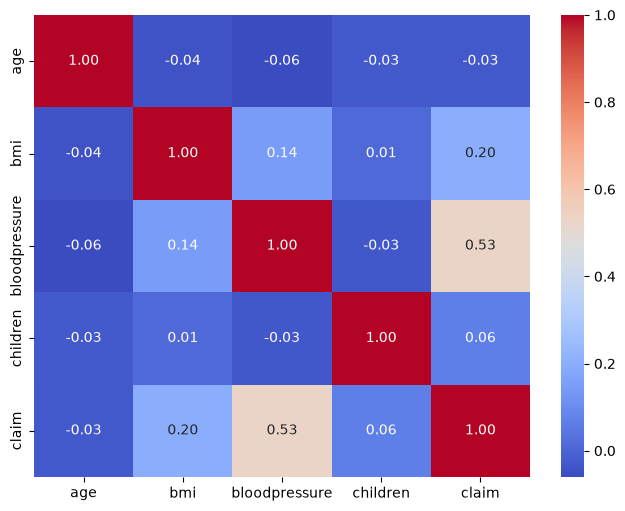

In [20]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_col].corr(), annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.show()

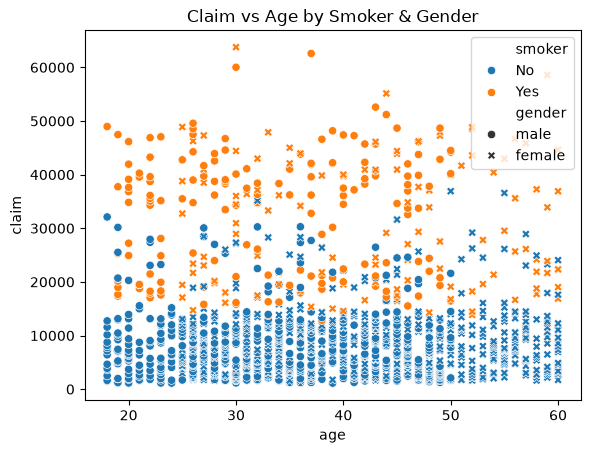

In [21]:
sns.scatterplot(data=df, x = 'age', y = 'claim', hue = 'smoker', style = 'gender')
plt.title('Claim vs Age by Smoker & Gender')
plt.show()

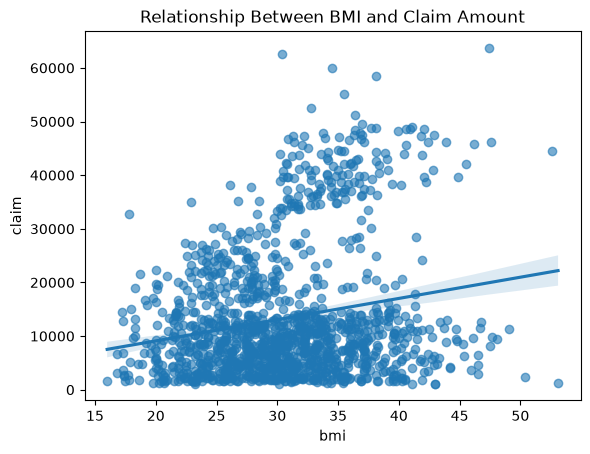

In [22]:
sns.regplot(data = df, x = 'bmi', y = 'claim', scatter_kws = {'alpha':0.6})
plt.title('Relationship Between BMI and Claim Amount')
plt.show()

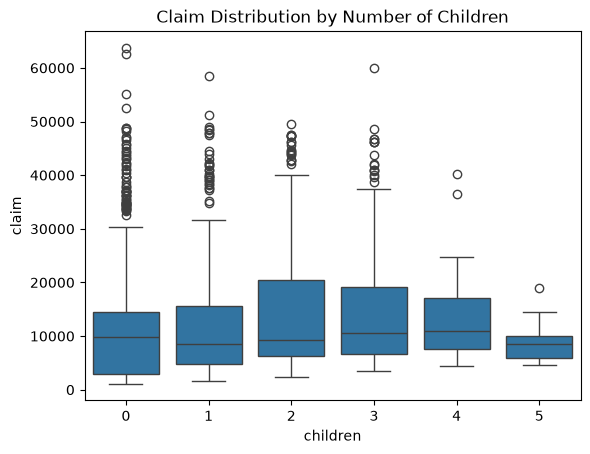

In [23]:
sns.boxplot(data = df, x = 'children', y = 'claim')
plt.title('Claim Distribution by Number of Children')
plt.show()

In [24]:
df['age_group'] = pd.cut(df['age'], bins = [0, 18, 30, 45, 60, 100], labels = ['<18', '18-30', '31-45', '46-60', '60+'])

In [25]:
df['age_group'].value_counts()

age_group
31-45    553
46-60    383
18-30    380
<18       16
60+        0
Name: count, dtype: int64

C:\Users\user\AppData\Local\Temp\ipykernel_24964\2245667195.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df, x='age_group', y='claim', estimator= 'mean', errorbar= 'sd', palette='Set2')


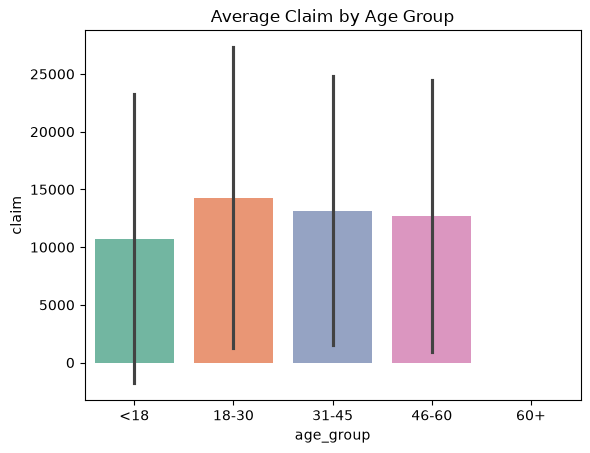

In [26]:
sns.barplot(data = df, x='age_group', y='claim', estimator= 'mean', errorbar= 'sd', palette='Set2')
plt.title('Average Claim by Age Group')
plt.show()

In [27]:
df['bmi_category'] = pd.cut(df['bmi'], bins= [0, 18.5, 24.9, 29.9, 100], labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
df['bmi_category'].value_counts()

bmi_category
Obese          702
Overweight     387
Normal         222
Underweight     21
Name: count, dtype: int64

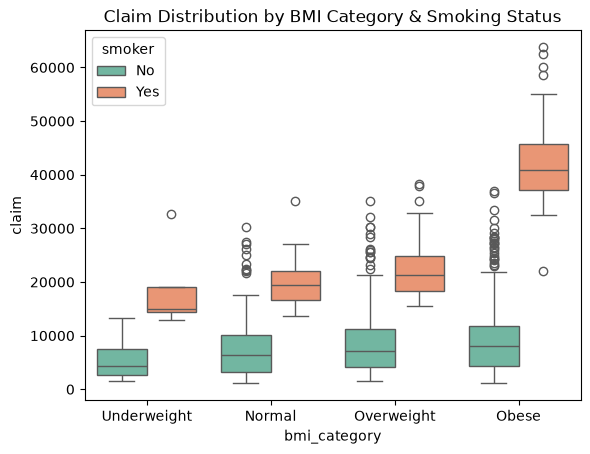

In [28]:
sns.boxplot(data = df, x = 'bmi_category', y='claim', hue='smoker', palette='Set2')
plt.title('Claim Distribution by BMI Category & Smoking Status')
plt.show()

In [29]:
region_stats = df.groupby('region').agg(
    smoker_rate = ('smoker', lambda x: (x=='Yes').mean() * 100),
    mean_claim = ('claim', 'mean')
).reset_index()

In [30]:
region_stats

,region,smoker_rate,mean_claim
0,northeast,29.004329,16889.044719
1,northwest,16.811594,11794.221855
2,southeast,20.588235,13085.496833
3,southwest,18.471338,12723.129841


In [31]:
import warnings

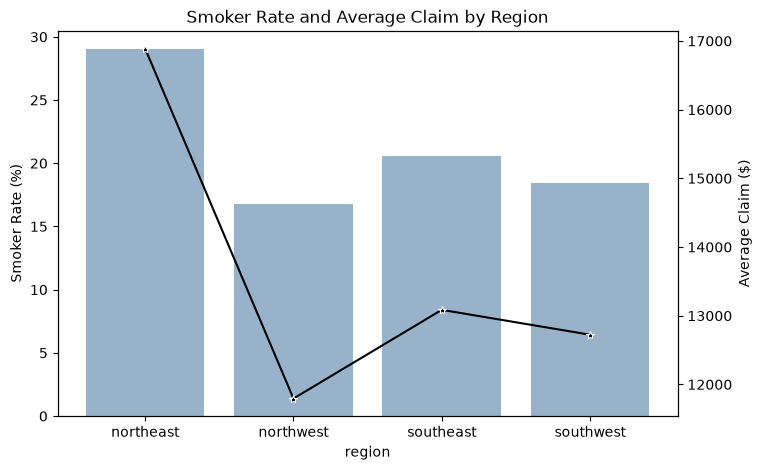

In [32]:
fig, ax1 = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=region_stats,
    x="region",
    y="smoker_rate",
    ax=ax1,
    alpha=0.6,
    color="steelblue"
)
ax2 = ax1.twinx()
sns.lineplot(data=region_stats, x="region", y="mean_claim", ax=ax2, color="black", marker="*")
ax1.set_ylabel("Smoker Rate (%)")
ax2.set_ylabel("Average Claim ($)")
plt.title("Smoker Rate and Average Claim by Region")
plt.show()

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib

In [34]:
X = df[['age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children', 'smoker']]
y = df['claim']

In [35]:
cat_col 

['gender', 'diabetic', 'smoker', 'region']

In [36]:
cat_col.pop()

'region'

In [49]:
cat_col 

label_encoders = {}

for col in cat_col:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    
    joblib.dump(le, f'label_encoder_{col}.pkl')

In [38]:
label_encoders

{'gender': LabelEncoder(),
 'diabetic': LabelEncoder(),
 'smoker': LabelEncoder()}

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [40]:
num_col = ['age', 'bmi', 'bloodpressure', 'children']
scaler = StandardScaler()

In [41]:
X_train[num_col] = scaler.fit_transform(X_train[num_col])
X_test[num_col] = scaler.fit_transform(X_test[num_col])

In [50]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [43]:
print(X_train.shape, y_train.shape)

(1065, 7) (1065,)


In [44]:
print(X_test.shape, y_test.shape)

(267, 7) (267,)


In [45]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor 

In [46]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    return {"R2":r2, "MAE":mae, "RMSE": rmse}

In [47]:
results = {}

In [51]:
from sklearn.pipeline import Pipeline

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        "R2": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
    }

results = {}

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
results["Linear Regression"] = evaluate_model(lr, X_test, y_test)

# Polynomial Regression: choose degree using training-only cross-validation
poly_pipeline = Pipeline([
    ("poly", PolynomialFeatures()),
    ("lr", LinearRegression()),
])
poly_grid = GridSearchCV(
    poly_pipeline,
    {"poly__degree": [2, 3]},
    cv=3,
    scoring="r2",
    n_jobs=-1,
)
poly_grid.fit(X_train, y_train)
best_poly_model = poly_grid.best_estimator_
best_degree = poly_grid.best_params_["poly__degree"]
results[f"Polynomial Regression (degree={best_degree})"] = evaluate_model(
    best_poly_model, X_test, y_test
)

# Support Vector Regression
svr_grid = GridSearchCV(
    SVR(),
    {
        "kernel": ["rbf", "poly", "linear"],
        "C": [1, 10, 50],
        "epsilon": [0.1, 0.2, 0.5],
        "degree": [2, 3],
    },
    cv=3,
    scoring="r2",
    n_jobs=-1,
)
svr_grid.fit(X_train, y_train)
best_svr = svr_grid.best_estimator_
results["SVR"] = evaluate_model(best_svr, X_test, y_test)

# Random Forest
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    {
        "n_estimators": [100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2],
    },
    cv=3,
    scoring="r2",
    n_jobs=-1,
)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
results["Random Forest"] = evaluate_model(best_rf, X_test, y_test)
print("Random Forest best parameters:", rf_grid.best_params_)

# XGBoost
xgb_grid = GridSearchCV(
    XGBRegressor(objective="reg:squarederror", random_state=42),
    {
        "n_estimators": [100, 200],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.01, 0.05, 0.1],
        "subsample": [0.8, 1.0],
    },
    cv=3,
    scoring="r2",
    n_jobs=-1,
)
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_
results["XGBoost"] = evaluate_model(best_xgb, X_test, y_test)
print("XGBoost best parameters:", xgb_grid.best_params_)

pd.DataFrame(results).T

Random Forest best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
XGBoost best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


,R2,MAE,RMSE
Linear Regression,0.719600,5073.234931,6357.269026
Polynomial Regression (degree=2),0.776564,4452.103577,5674.903172
SVR,0.508299,5913.359072,8418.448955
Random Forest,0.807665,4026.763862,5265.142606
XGBoost,0.827838,3853.216254,4981.384613


In [52]:
results_df = pd.DataFrame(results).T.sort_values(by='R2', ascending=False)
results_df

,R2,MAE,RMSE
XGBoost,0.827838,3853.216254,4981.384613
Random Forest,0.807665,4026.763862,5265.142606
Polynomial Regression (degree=2),0.776564,4452.103577,5674.903172
Linear Regression,0.719600,5073.234931,6357.269026
SVR,0.508299,5913.359072,8418.448955


In [53]:
models = {
    'Linear Regression': lr,
    'Polynomial Regression': best_poly_model,
    'Random Forest': best_rf,
    'SVR': best_svr,
    'XGboost': best_xgb
}

In [ ]:
best_r2 = results_df['R2'].max()

In [57]:
top_model = results_df[results_df['R2'] == best_r2]
top_model

,R2,MAE,RMSE
XGBoost,0.827838,3853.216254,4981.384613


In [60]:
models = {
    "Linear Regression": lr,
    f"Polynomial Regression (degree={best_degree})": best_poly_model,
    "Random Forest": best_rf,
    "SVR": best_svr,
    "XGBoost": best_xgb,
}

best_model = models[top_model.index[0]]

In [61]:
best_model

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [62]:
joblib.dump(best_model, 'best_model.pkl')
print(f'Best model selected: {top_model.index[0]}')

Best model selected: XGBoost
